# Chronos-2 as a Universal Transfer Benchmark for Limit Order Book Mid-Price Forecasting

---

## Overview

This notebook evaluates **Chronos-2**, a 120M-parameter, encoder-only universal time series foundation model as a domain transfer benchmark on Limit Order Book (LOB) data. Chronos-2 extends the original Chronos architecture with a group-attention mechanism that enables native multivariate and covariate-informed forecasting.

We assess **three experimental conditions** designed to isolate the contribution of each training source:

| Condition | Training Data | Evaluation |
|-----------|--------------|------------|
| **Zero-shot** | None (pretrained only) | LOBSTER (AAPL) |
| **FI-2010 fine-tuned** | FI-2010 Nordic NASDAQ | LOBSTER (AAPL) |
| **FI-2010 + LOBS5 fine-tuned** | FI-2010 + LOBS5 synthetic | LOBSTER (AAPL) |

---

## Datasets

| Dataset | Market | Type | Scale | Source |
|---------|--------|------|-------|--------|
| **FI-2010** | NASDAQ Nordic (Finland) | Real | ~1M events, 10 days | Local (`data (1)/`) |
| **LOBS5** | Synthetic (GOOG-like) | Generated | ~72K events | `peernagy/lob_bench` (HuggingFace) |
| **LOBSTER** | US Equities (AAPL) | Real | ~400K events | `totalorganfailure/lobster-data` (HuggingFace) |

## Evaluation Protocol

For each horizon $k \in \{10, 20, 50\}$:
- **Context window**: $T = 100$ LOB snapshots (matching DeepLOB's input shape)
- **Task**: 3-class mid-price movement classification $\{\downarrow, \leftrightarrow, \uparrow\}$
- **Label conversion**: Chronos-2 predicts $k$-step mid-price; median quantile forecast determines direction
- **Metrics**: Macro-F1, per-class F1, accuracy

Labels use an **absolute** threshold $\varepsilon = 10^{-5}$ USD on mid-price change:

$$l_t^{(k)} = \begin{cases} \uparrow & \text{if } m(t+k) - m(t) > \varepsilon \\ \downarrow & \text{if } m(t+k) - m(t) < -\varepsilon \\ \leftrightarrow & \text{otherwise} \end{cases}$$

---
## Section 1 — Environment Setup

In [ ]:
# Install required packages
# chronos-forecasting>=2.1.0 is required for Chronos-2 fine-tuning support
!pip install "chronos-forecasting>=2.1.0" huggingface_hub datasets scikit-learn -q

In [ ]:
import warnings
import json
import time
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from huggingface_hub import hf_hub_download, list_repo_files

from chronos import BaseChronosPipeline, Chronos2Pipeline
from chronos.chronos2.dataset import Chronos2Dataset
from chronos.chronos2.trainer import Chronos2Trainer
from transformers import TrainingArguments

warnings.filterwarnings("ignore")

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"PyTorch version : {torch.__version__}")
print(f"Compute device  : {DEVICE}")

/Users/ryantobin/cis7000/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.11.0
Compute device  : mps


In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Data Sources ───────────────────────────────────────────────────────────────
FI2010_DATA_ROOT  = Path("data (1)")
LOBSTER_REPO_ID   = "totalorganfailure/lobster-data"
LOBS5_REPO_ID     = "peernagy/lob_bench"
CHRONOS_MODEL_ID  = "amazon/chronos-2"
CHECKPOINT_DIR    = Path("chronos2_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

LOBSTER_FILES = {
    "AAPL": {
        "orderbook": "LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv",
        "message"  : "LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_message_10.csv",
    }
}
LOBSTER_TICKERS_AVAILABLE = list(LOBSTER_FILES.keys())

# ── Dataset Parameters ─────────────────────────────────────────────────────────
LOBS5_TICKER      = "GOOG"
LOBS5_RUN_DIR     = "data_gen_lobs5"
LOBS5_MAX_FILES   = 150
N_LOB_LEVELS      = 10

# ── Evaluation Parameters ──────────────────────────────────────────────────────
HORIZONS          = [10, 20, 50]   # k ∈ {10, 20, 50} events ahead
MAX_HORIZON       = max(HORIZONS)  # 50 — longest prediction horizon
CONTEXT_LENGTH    = 100            # T = 100 LOB snapshots (DeepLOB-equivalent)
EVAL_STRIDE       = 10             # Step between successive evaluation windows
N_EVAL_WINDOWS    = 2000           # Maximum windows evaluated per stock
EVAL_BATCH_SIZE   = 200            # Windows processed per predict_df() call
STATIONARY_EPS    = 1e-5           # absolute USD

# ── Fine-tuning Parameters ─────────────────────────────────────────────────────
FINETUNE_CONTEXT  = 512
FINETUNE_BATCH    = 32
FINETUNE_LR       = 1e-4
FINETUNE_EPOCHS   = 3
OUTPUT_PATCH_SIZE = 16

# ── LOB Feature Column Names (40 raw features, N_LOB_LEVELS levels) ────────────
LOB_COV_COLS = []
for lvl in range(1, N_LOB_LEVELS + 1):
    LOB_COV_COLS += [
        f"ask_price_{lvl}", f"ask_vol_{lvl}",
        f"bid_price_{lvl}", f"bid_vol_{lvl}",
    ]
assert len(LOB_COV_COLS) == 40, "Expected 40 raw LOB feature columns"

plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
})
PALETTE = sns.color_palette("colorblind", 6)
LABEL_NAMES = {0: "Down", 1: "Stationary", 2: "Up"}

print("Configuration loaded.")
print(f"  LOBSTER tickers       : {LOBSTER_TICKERS_AVAILABLE}")
print(f"  LOB covariate columns : {len(LOB_COV_COLS)}")
print(f"  Evaluation horizons   : k ∈ {HORIZONS}")
print(f"  Stationary threshold  : ε = {STATIONARY_EPS} (absolute USD)")

Configuration loaded.
  LOBSTER tickers       : ['AAPL']
  LOB covariate columns : 40
  Evaluation horizons   : k ∈ [10, 20, 50]
  Stationary threshold  : ε = 1e-05 (absolute USD)


---
## Section 2 — FI-2010 Data Loading

FI-2010 is the standard benchmark for LOB price prediction (Ntakaris et al., 2018). We use 7-day training, 3-day test with Decimal Precision (DecPre) normalization. The dataset contains 10 levels of bid/ask prices and volumes for 5 NASDAQ Nordic stocks.

Each row in the raw file corresponds to one LOB snapshot. The last 5 rows encode pre-computed labels at horizons $k \in \{10, 20, 30, 50, 100\}$, with class encoding $\{1=\downarrow, 2=\leftrightarrow, 3=\uparrow\}$.

In [ ]:
def load_fi2010(
    data_root: Path,
    horizon_idx: int = 0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load FI-2010 Setup 2 from flat DecPre-normalized .txt files.

    File layout (149 rows × N timesteps):
      rows  0–39  : 40 raw LOB features (ask/bid price+vol × 10 levels)
      rows 40–143 : handcrafted features
      rows 144–148: labels at k={10,20,30,50,100} (values 1,2,3)

    Returns X_train (N_tr, 40), y_train (N_tr,),
            X_test  (N_te, 40), y_test  (N_te,)   — labels in {0,1,2}.
    """
    label_row = 144 + horizon_idx

    train_files = sorted(data_root.glob("Train_Dst_NoAuction_DecPre_CF_*.txt"))
    test_files  = sorted(data_root.glob("Test_Dst_NoAuction_DecPre_CF_*.txt"))

    if not train_files:
        raise FileNotFoundError(
            f"No FI-2010 training files found in {data_root}. "
            "Expected: Train_Dst_NoAuction_DecPre_CF_*.txt"
        )

    def _load(files, label_row):
        X_parts, y_parts = [], []
        for f in files:
            arr = np.loadtxt(f)                        # shape: (149, N)
            X_parts.append(arr[:40, :].T.astype(np.float32))  # (N, 40)
            y_parts.append(arr[label_row, :].astype(int) - 1) # {0,1,2}
        return np.concatenate(X_parts, axis=0), np.concatenate(y_parts, axis=0)

    X_train, y_train = _load(train_files, label_row)
    X_test,  y_test  = _load(test_files,  label_row)
    return X_train, y_train, X_test, y_test


def fi2010_mid_price(X: np.ndarray) -> np.ndarray:
    return (X[:, 0] + X[:, 2]) / 2.0

In [ ]:
print("Loading FI-2010 (Setup 2, DecPre normalization)...")

fi2010 = {}
horizon_idx_map = {10: 0, 20: 1, 50: 3}   # FI-2010 file label row indices

for k in HORIZONS:
    X_tr, y_tr, X_te, y_te = load_fi2010(FI2010_DATA_ROOT, horizon_idx=horizon_idx_map[k])
    fi2010[k] = {"X_train": X_tr, "y_train": y_tr, "X_test": X_te, "y_test": y_te}

fi2010_X_train = fi2010[10]["X_train"]
fi2010_X_test  = fi2010[10]["X_test"]
fi2010_mid_train = fi2010_mid_price(fi2010_X_train)
fi2010_mid_test  = fi2010_mid_price(fi2010_X_test)

print(f"  Training set : {fi2010_X_train.shape[0]:,} snapshots × {fi2010_X_train.shape[1]} features")
print(f"  Test set     : {fi2010_X_test.shape[0]:,} snapshots × {fi2010_X_test.shape[1]} features")
print()

# Label distribution summary
print("Label distribution (training, %)")
header = f"  {'Horizon':>8}  {'Down':>8}  {'Stat':>8}  {'Up':>8}"
print(header)
for k in HORIZONS:
    y = fi2010[k]["y_train"]
    counts = np.bincount(y, minlength=3) / len(y) * 100
    print(f"  k={k:>5}    {counts[0]:>7.1f}%  {counts[1]:>7.1f}%  {counts[2]:>7.1f}%")

Loading FI-2010 (Setup 2, DecPre normalization)...
  Training set : 254,750 snapshots × 40 features
  Test set     : 139,587 snapshots × 40 features

Label distribution (training, %)
   Horizon      Down      Stat        Up
  k=   10       19.7%     60.5%     19.7%
  k=   20       25.4%     49.4%     25.2%
  k=   50       34.4%     31.7%     33.9%


---
## Section 3 — LOBSTER Data Loading

LOBSTER provides high-fidelity US equity LOB data at 10 levels of depth. We load five stocks from `totalorganfailure/lobster-data` on HuggingFace, spanning one full trading day (2012-06-21, 09:30–16:00 ET). These constitute our **target domain** for evaluating transfer.

Prices are stored in units of $10^{-4}$ USD and are converted to dollars on load. Mid-price and classification labels are computed identically to the FI-2010 convention.

In [ ]:
print("LOBSTER file paths:")
for ticker, paths in LOBSTER_FILES.items():
    print(f"  {ticker}:")
    print(f"    orderbook : {paths['orderbook']}")
    print(f"    message   : {paths['message']}")

LOBSTER file paths:
  AAPL:
    orderbook : LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv
    message   : LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_message_10.csv


In [ ]:
def load_lobster_orderbook(filepath: str, n_levels: int = 10) -> pd.DataFrame:
    cols = []
    for i in range(1, n_levels + 1):
        cols += [f"ask_price_{i}", f"ask_vol_{i}", f"bid_price_{i}", f"bid_vol_{i}"]
    df = pd.read_csv(filepath, header=None, names=cols)
    price_cols = [c for c in df.columns if "price" in c]
    df[price_cols] = df[price_cols] / 10_000.0  # convert from 1/10000 USD to USD
    return df


def load_lobster_message(filepath: str) -> pd.DataFrame:
    cols = ["time", "event_type", "order_id", "size", "price", "direction"]
    df = pd.read_csv(filepath, header=None, names=cols)
    df["price"] = df["price"] / 10_000.0
    return df


def compute_lobster_features(
    ob: pd.DataFrame,
    msg: pd.DataFrame,
    n_levels: int = 10,
    eps: float = STATIONARY_EPS,
) -> pd.DataFrame:
    """
    Compute LOB features and 3-class directional labels for LOBSTER data.

    Labels use an absolute threshold ε on mid-price change (consistent with
    LOB_Domain_Shift_Quantification.ipynb). For AAPL at ~$580 with ε=1e-5,
    any non-zero half-tick move is classified as directional.

      Up (2)        :  m(t+k) - m(t) >  ε
      Down (0)      :  m(t+k) - m(t) < -ε
      Stationary (1): otherwise
    """
    f = pd.DataFrame(index=ob.index)

    for lvl in range(1, n_levels + 1):
        for col in [f"ask_price_{lvl}", f"ask_vol_{lvl}",
                    f"bid_price_{lvl}", f"bid_vol_{lvl}"]:
            f[col] = ob[col].values

    f["mid_price"]       = (ob["ask_price_1"].values + ob["bid_price_1"].values) / 2.0
    f["spread"]          = ob["ask_price_1"].values - ob["bid_price_1"].values
    f["time"]            = msg["time"].values

    bid_vols = ob[[f"bid_vol_{i}" for i in range(1, n_levels + 1)]].values.sum(axis=1)
    ask_vols = ob[[f"ask_vol_{i}" for i in range(1, n_levels + 1)]].values.sum(axis=1)
    denom = bid_vols + ask_vols
    f["order_imbalance"] = np.where(denom > 0, (bid_vols - ask_vols) / denom, 0.0)

    # 3-class labels at each horizon
    mp = f["mid_price"].values
    for k in HORIZONS:
        future = np.full_like(mp, np.nan)
        future[:-k] = mp[k:]
        diff  = future - mp
        label = np.where(diff >  eps, 2,
                np.where(diff < -eps, 0, 1)).astype(float)
        label[np.isnan(diff)] = np.nan
        f[f"label_k{k}"] = label

    # Drop only rows with NaN in core level-1 price/volume columns
    core_cols = ["mid_price", "spread", "ask_price_1", "bid_price_1",
                 "ask_vol_1", "bid_vol_1"]
    return f.replace([np.inf, -np.inf], np.nan).dropna(
        subset=core_cols
    ).reset_index(drop=True)

In [ ]:
print("Loading LOBSTER data from HuggingFace...")

lobster_features: Dict[str, pd.DataFrame] = {}

for ticker, paths in LOBSTER_FILES.items():
    ob_path  = hf_hub_download(
        repo_id   = LOBSTER_REPO_ID,
        filename  = paths["orderbook"],
        repo_type = "dataset",
    )
    msg_path = hf_hub_download(
        repo_id   = LOBSTER_REPO_ID,
        filename  = paths["message"],
        repo_type = "dataset",
    )
    ob   = load_lobster_orderbook(ob_path,  n_levels=N_LOB_LEVELS)
    msg  = load_lobster_message(msg_path)
    feat = compute_lobster_features(ob, msg, n_levels=N_LOB_LEVELS)
    lobster_features[ticker] = feat
    print(f"  {ticker}: {len(feat):,} snapshots loaded")

print()
print("LOBSTER summary statistics:")
rows = []
for ticker, feat in lobster_features.items():
    rows.append({
        "Ticker"     : ticker,
        "N events"   : f"{len(feat):,}",
        "Avg spread" : f"${feat['spread'].mean():.4f}",
        "Mid-price μ": f"${feat['mid_price'].mean():.2f}",
        "Mid-price σ": f"${feat['mid_price'].std():.4f}",
        "Avg |imbal|": f"{feat['order_imbalance'].abs().mean():.4f}",
    })
summary_df = pd.DataFrame(rows).set_index("Ticker")
display(summary_df)

print("\nLOBSTER label distribution (%, should resemble FI-2010):")
print(f"  {'Horizon':>8}  {'Down':>8}  {'Stat':>8}  {'Up':>8}")
for ticker, feat in lobster_features.items():
    for k in HORIZONS:
        col = f"label_k{k}"
        valid = feat[col].dropna()
        if len(valid) == 0:
            continue
        counts = np.bincount(valid.astype(int), minlength=3) / len(valid) * 100
        print(f"  {ticker} k={k:>2}    {counts[0]:>7.1f}%  {counts[1]:>7.1f}%  {counts[2]:>7.1f}%")

Loading LOBSTER data from HuggingFace...
  AAPL: 400,391 snapshots loaded

LOBSTER summary statistics:


,N events,Avg spread,Mid-price μ,Mid-price σ,Avg |imbal|
Ticker,,,,,
AAPL,"400,391",$0.1535,$583.15,$2.8350,0.2901



LOBSTER label distribution (%, should resemble FI-2010):
   Horizon      Down      Stat        Up
  AAPL k=10       32.4%     36.2%     31.4%
  AAPL k=20       41.1%     20.0%     38.9%
  AAPL k=50       48.1%      7.4%     44.5%


---
## Section 4 — LOBS5 Synthetic Data Loading

LOBS5 provides synthetic LOB data generated to approximate real equity microstructure dynamics. We reconstruct order book snapshots from raw message files via event-by-event replay, the same procedure used in our domain shift quantification analysis.

LOBS5 serves as **additional pre-training data** in Condition 3, acting as a data augmentation source that lies between the FI-2010 domain and the LOBSTER target domain. Our research question: does synthetic augmentation improve cross-market transfer?

In [ ]:
def load_lobs5_and_reconstruct(
    repo_id: str,
    ticker: str,
    run_dir: str,
    max_files: int = 150,
    n_levels: int = 10,
) -> pd.DataFrame:
    all_files = list(list_repo_files(repo_id, repo_type="dataset"))
    prefix = f"{ticker}/{run_dir}/"
    msg_files = sorted(
        [f for f in all_files if f.startswith(prefix) and "_message_" in f and f.endswith(".csv")]
    )[:max_files]

    if not msg_files:
        raise ValueError(f"No LOBS5 message files found under {prefix}")

    def _best_bid(levels): return max(levels) if levels else np.nan
    def _best_ask(levels): return min(levels) if levels else np.nan

    def _add_level(levels, price, delta):
        if not np.isfinite(price) or delta == 0:
            return
        v = levels.get(price, 0.0) + float(delta)
        if v <= 0:
            levels.pop(price, None)
        else:
            levels[price] = v

    def _snapshot(bid_levels, ask_levels, time_val):
        snap = {"time": time_val}
        bid_prices = sorted(bid_levels, reverse=True)[:n_levels]
        ask_prices = sorted(ask_levels)[:n_levels]
        for i in range(1, n_levels + 1):
            bp = bid_prices[i - 1] if i - 1 < len(bid_prices) else np.nan
            ap = ask_prices[i - 1] if i - 1 < len(ask_prices) else np.nan
            snap[f"bid_price_{i}"] = bp
            snap[f"bid_vol_{i}"]   = float(bid_levels.get(bp, 0.0)) if np.isfinite(bp if bp is not None else np.nan) else 0.0
            snap[f"ask_price_{i}"] = ap
            snap[f"ask_vol_{i}"]   = float(ask_levels.get(ap, 0.0)) if np.isfinite(ap if ap is not None else np.nan) else 0.0
        return snap

    def _load_msg(path):
        cols = ["time", "event_type", "order_id", "size", "price", "direction"]
        m = pd.read_csv(path, header=None, names=cols)
        for c in cols:
            m[c] = pd.to_numeric(m[c], errors="coerce")
        if np.isfinite(m["price"].median()) and m["price"].median() > 1e4:
            m["price"] /= 10_000.0
        return m

    segments = []
    for seg_idx, hf_path in enumerate(tqdm(msg_files, desc="Reconstructing LOBS5")):
        local_path = hf_hub_download(repo_id=repo_id, filename=hf_path, repo_type="dataset")
        m = _load_msg(local_path)
        orders, bid_levels, ask_levels, snaps = {}, {}, {}, []

        for _, r in m.iterrows():
            t   = r["time"]
            et  = r["event_type"]
            oid = r["order_id"]
            sz  = r["size"]
            px  = r["price"]
            d   = r["direction"]

            if any(pd.isna(v) for v in [et, oid, sz, px, d]) or sz <= 0:
                snaps.append(_snapshot(bid_levels, ask_levels, t))
                continue

            et, oid, d = int(et), int(oid), int(d)

            if et == 1:  # New limit order
                remaining = sz
                side_levels = ask_levels if d == 1 else bid_levels
                opp_levels  = bid_levels if d == 1 else ask_levels
                while remaining > 0 and opp_levels:
                    best = _best_ask(opp_levels) if d == 1 else _best_bid(opp_levels)
                    if not np.isfinite(best if best is not None else np.nan):
                        break
                    if (d == 1 and px < best) or (d == -1 and px > best):
                        break
                    traded = min(remaining, opp_levels[best])
                    opp_levels[best] -= traded
                    if opp_levels[best] <= 0:
                        del opp_levels[best]
                    remaining -= traded
                if remaining > 0:
                    orders[oid] = (d, px, remaining)
                    _add_level(side_levels, px, remaining)

            elif et in (2, 4, 5) and oid in orders:  # Cancel / partial fill
                od, op, os_ = orders[oid]
                delta = min(sz, os_)
                _add_level(bid_levels if od == 1 else ask_levels, op, -delta)
                remaining = os_ - delta
                if remaining <= 0:
                    del orders[oid]
                else:
                    orders[oid] = (od, op, remaining)

            elif et == 3 and oid in orders:  # Full cancel
                od, op, os_ = orders[oid]
                _add_level(bid_levels if od == 1 else ask_levels, op, -os_)
                del orders[oid]

            snaps.append(_snapshot(bid_levels, ask_levels, t))

        seg_df = pd.DataFrame(snaps)
        seg_df["segment_id"] = f"{ticker}_{run_dir}_{seg_idx:05d}"
        segments.append(seg_df)

    ob_all = pd.concat(segments, ignore_index=True)

    # Compute mid-price and reorder columns to match FI-2010 convention
    ob_all["mid_price"] = (ob_all["ask_price_1"] + ob_all["bid_price_1"]) / 2.0
    ob_all = ob_all.replace([np.inf, -np.inf], np.nan)

    return ob_all

In [ ]:
print("Loading LOBS5 synthetic data from HuggingFace...")
print(f"  Ticker: {LOBS5_TICKER} | Run dir: {LOBS5_RUN_DIR} | Max files: {LOBS5_MAX_FILES}")

lobs5_ob = load_lobs5_and_reconstruct(
    repo_id  = LOBS5_REPO_ID,
    ticker   = LOBS5_TICKER,
    run_dir  = LOBS5_RUN_DIR,
    max_files= LOBS5_MAX_FILES,
    n_levels = N_LOB_LEVELS,
)

# Build LOB feature matrix (N, 40) from reconstructed snapshots
lobs5_X = lobs5_ob[LOB_COV_COLS].values.astype(np.float32)
lobs5_mid = lobs5_ob["mid_price"].values.astype(np.float32)

# Drop rows with NaN features
valid_mask = np.isfinite(lobs5_X).all(axis=1) & np.isfinite(lobs5_mid)
lobs5_X   = lobs5_X[valid_mask]
lobs5_mid = lobs5_mid[valid_mask]

print(f"\n  LOBS5 snapshots (after NaN removal): {len(lobs5_X):,}")
print(f"  Mid-price range: [{lobs5_mid.min():.4f}, {lobs5_mid.max():.4f}]")
print(f"  Mid-price mean : {lobs5_mid.mean():.4f} ± {lobs5_mid.std():.4f}")

Loading LOBS5 synthetic data from HuggingFace...
  Ticker: GOOG | Run dir: data_gen_lobs5 | Max files: 150


Reconstructing LOBS5: 100%|██████████| 150/150 [00:18<00:00,  8.29it/s]


  LOBS5 snapshots (after NaN removal): 22,119
  Mid-price range: [88.0450, 91.0750]
  Mid-price mean : 89.6999 ± 0.5076


---
## Section 5 — Chronos-2 Format Conversion and Label Generation

Chronos-2 accepts time series in pandas DataFrames with the following required columns:
- `item_id` — unique identifier for each time series / context window
- `timestamp` — monotonically increasing datetime index within each item
- `target` — the forecast target (here: mid-price)
- *Additional columns* — treated as past covariates (here: the 40 raw LOB features)

For evaluation, we create **sliding windows** of $T = 100$ timesteps, each as a separate `item_id`. Chronos-2 then generates $k$-step ahead probabilistic forecasts for each window. The **median quantile** (0.5) of the forecast at step $k$ is compared against the context's final mid-price to assign an up/down/stationary label.

In [ ]:
_TS_BASE = pd.Timestamp("2020-01-01")


def build_eval_df(
    mid_price     : np.ndarray,
    lob_features  : np.ndarray,
    covariate_cols: List[str],
    item_prefix   : str,
    context_length: int = 100,
    stride        : int = 10,
    max_windows   : int = 2000,
) -> Tuple[pd.DataFrame, List[int]]:
    """
    Convert a LOB array into a Chronos-2 long-format evaluation DataFrame.
    Each context window of length `context_length` becomes one `item_id`.
    Returns (context_df, window_start_indices).
    """
    n = len(mid_price)
    records = []
    window_starts = []

    for w_idx, start in enumerate(range(0, n - context_length - MAX_HORIZON, stride)):
        if w_idx >= max_windows:
            break
        end = start + context_length
        item_id = f"{item_prefix}_{w_idx:06d}"
        window_starts.append(start)
        window_mp   = mid_price[start:end]
        window_feat = lob_features[start:end]

        for t in range(context_length):
            rec = {
                "item_id"  : item_id,
                "timestamp": _TS_BASE + pd.Timedelta(seconds=t),
                "target"   : float(window_mp[t]),
            }
            for j, col in enumerate(covariate_cols):
                rec[col] = float(window_feat[t, j])
            records.append(rec)

    return pd.DataFrame(records), window_starts


def compute_ground_truth_labels(
    mid_price     : np.ndarray,
    window_starts : List[int],
    context_length: int,
    horizon       : int,
    eps           : float = STATIONARY_EPS,
) -> np.ndarray:
    labels = []
    for start in window_starts:
        current_idx = start + context_length - 1
        future_idx  = current_idx + horizon
        if future_idx >= len(mid_price):
            labels.append(-1)
            continue
        diff = mid_price[future_idx] - mid_price[current_idx]
        if diff >  eps:
            labels.append(2)
        elif diff < -eps:
            labels.append(0)
        else:
            labels.append(1)
    return np.array(labels)


def forecast_to_label(
    pred_price   : float,
    current_price: float,
    eps          : float = STATIONARY_EPS,
) -> int:
    diff = pred_price - current_price
    if diff >  eps:
        return 2
    elif diff < -eps:
        return 0
    return 1


print("Format conversion utilities defined.")
print(f"  Threshold: ε = {STATIONARY_EPS} (absolute USD, consistent with project notebooks)")

Format conversion utilities defined.
  Threshold: ε = 1e-05 (absolute USD, consistent with project notebooks)


In [ ]:
def prepare_finetune_inputs(
    mid_price      : np.ndarray,
    lob_features   : np.ndarray,
    covariate_cols : List[str],
    segment_length : int = 512,
    stride_ratio   : float = 0.5,
) -> List[Dict[str, Any]]:
    inputs = []
    stride = int(segment_length * stride_ratio)
    n = len(mid_price)

    for start in range(0, n - segment_length, stride):
        end = start + segment_length
        if end > n:
            break
        seg_target = mid_price[start:end].astype(np.float32)

        # Drop segments with non-finite values
        if not np.isfinite(seg_target).all():
            continue

        past_covs = {}
        valid = True
        for j, col in enumerate(covariate_cols):
            seg_cov = lob_features[start:end, j].astype(np.float32)
            if not np.isfinite(seg_cov).all():
                valid = False
                break
            past_covs[col] = seg_cov

        if valid:
            inputs.append({"target": seg_target, "past_covariates": past_covs})

    return inputs


print("Fine-tuning preparation utilities defined.")

Fine-tuning preparation utilities defined.


---
## Section 6 — Chronos-2 Zero-Shot Evaluation

We first evaluate Chronos-2 **without any LOB-specific training**, assessing what a pretrained universal time series model can achieve out-of-the-box. The model receives the full 40-feature LOB snapshot as past covariates alongside mid-price as the target, and produces a probabilistic forecast $k$ steps ahead.

This establishes the **zero-shot baseline** — the lower bound for cross-market transfer without domain adaptation.

In [ ]:
print(f"Loading Chronos-2 from '{CHRONOS_MODEL_ID}'...")
t0 = time.time()

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    CHRONOS_MODEL_ID,
    device_map=DEVICE,
)

print(f"Model loaded in {time.time() - t0:.1f}s")
print(f"  Architecture : {type(pipeline).__name__}")
print(f"  Device       : {DEVICE}")
n_params = sum(p.numel() for p in pipeline.model.parameters())
print(f"  Parameters   : {n_params / 1e6:.1f}M")

Loading Chronos-2 from 'amazon/chronos-2'...
Model loaded in 0.9s
  Architecture : Chronos2Pipeline
  Device       : mps
  Parameters   : 119.5M


In [ ]:
def evaluate_chronos_on_lobster(
    pipeline       : Chronos2Pipeline,
    ticker         : str,
    feat_df        : pd.DataFrame,
    horizon        : int,
    context_length : int = CONTEXT_LENGTH,
    stride         : int = EVAL_STRIDE,
    n_windows      : int = N_EVAL_WINDOWS,
    batch_size     : int = EVAL_BATCH_SIZE,
) -> Dict[str, Any]:
    """
    Evaluate Chronos-2 on a LOBSTER ticker at a given prediction horizon.

    Windows are processed in batches to avoid memory exhaustion. The median
    quantile (q=0.5) of the forecast at step k determines the predicted label.

    Returns a dict with F1 macro, per-class F1, accuracy, and metadata.
    """
    mid_price    = feat_df["mid_price"].values.astype(np.float64)
    lob_features = feat_df[LOB_COV_COLS].values.astype(np.float32)

    # Build sliding windows
    context_df, window_starts = build_eval_df(
        mid_price      = mid_price,
        lob_features   = lob_features,
        covariate_cols = LOB_COV_COLS,
        item_prefix    = ticker,
        context_length = context_length,
        stride         = stride,
        max_windows    = n_windows,
    )

    all_item_ids = context_df["item_id"].unique().tolist()
    n_actual = len(all_item_ids)

    # Ground-truth labels
    y_true = compute_ground_truth_labels(
        mid_price, window_starts[:n_actual], context_length, horizon
    )
    valid_mask = y_true >= 0

    # Run batched Chronos-2 inference
    pred_median: Dict[str, float] = {}

    for batch_start in tqdm(
        range(0, n_actual, batch_size),
        desc=f"{ticker} k={horizon}",
        leave=False,
    ):
        batch_ids = all_item_ids[batch_start : batch_start + batch_size]
        batch_df  = context_df[context_df["item_id"].isin(batch_ids)].copy()

        pred_df = pipeline.predict_df(
            batch_df,
            prediction_length = horizon,
            quantile_levels   = [0.5],
            id_column         = "item_id",
            timestamp_column  = "timestamp",
            target            = "target",
        )

        # Extract the forecast value at the final prediction step (step k)
        last_step = (
            pred_df
            .sort_values(["item_id", "timestamp"])
            .groupby("item_id")
            .last()["0.5"]
        )
        pred_median.update(last_step.to_dict())

    # Build predicted labels
    y_pred = np.full(n_actual, -1, dtype=int)
    for i, item_id in enumerate(all_item_ids):
        if item_id in pred_median:
            current_price = mid_price[window_starts[i] + context_length - 1]
            y_pred[i] = forecast_to_label(pred_median[item_id], current_price)

    # Apply validity mask
    keep = valid_mask & (y_pred >= 0)
    y_true_f = y_true[keep]
    y_pred_f = y_pred[keep]

    if len(y_true_f) == 0:
        return {"ticker": ticker, "horizon": horizon, "error": "no valid samples"}

    f1_macro    = f1_score(y_true_f, y_pred_f, average="macro",  zero_division=0)
    f1_per_cls  = f1_score(y_true_f, y_pred_f, average=None,
                           labels=[0, 1, 2],    zero_division=0)
    accuracy    = (y_true_f == y_pred_f).mean()

    return {
        "ticker"       : ticker,
        "horizon"      : horizon,
        "f1_macro"     : f1_macro,
        "f1_down"      : f1_per_cls[0],
        "f1_stationary": f1_per_cls[1],
        "f1_up"        : f1_per_cls[2],
        "accuracy"     : accuracy,
        "n_samples"    : len(y_true_f),
        "y_true"       : y_true_f,
        "y_pred"       : y_pred_f,
    }


print("Evaluation function defined.")

Evaluation function defined.


In [ ]:
print("=" * 60)
print("CONDITION 1: Zero-Shot Evaluation")
print("=" * 60)

zero_shot_results: List[Dict] = []

for ticker in LOBSTER_TICKERS_AVAILABLE:
    feat_df = lobster_features[ticker]
    for k in HORIZONS:
        result = evaluate_chronos_on_lobster(
            pipeline = pipeline,
            ticker   = ticker,
            feat_df  = feat_df,
            horizon  = k,
        )
        zero_shot_results.append(result)
        print(
            f"  {ticker} k={k:>2} | "
            f"F1-macro={result.get('f1_macro', float('nan')):.4f} | "
            f"Acc={result.get('accuracy', float('nan')):.4f} | "
            f"n={result.get('n_samples', 0)}"
        )

print("\nZero-shot evaluation complete.")

CONDITION 1: Zero-Shot Evaluation


  AAPL k=10 | F1-macro=0.3221 | Acc=0.4395 | n=2000


  AAPL k=20 | F1-macro=0.3131 | Acc=0.4385 | n=2000


  AAPL k=50 | F1-macro=0.3011 | Acc=0.4425 | n=2000

Zero-shot evaluation complete.


In [ ]:
def results_to_df(results: List[Dict], condition: str) -> pd.DataFrame:
    rows = [
        {
            "Condition" : condition,
            "Ticker"    : r["ticker"],
            "k"         : r["horizon"],
            "F1 Macro"  : r.get("f1_macro",      np.nan),
            "F1 Down"   : r.get("f1_down",        np.nan),
            "F1 Stat"   : r.get("f1_stationary",  np.nan),
            "F1 Up"     : r.get("f1_up",          np.nan),
            "Accuracy"  : r.get("accuracy",        np.nan),
            "N Samples" : r.get("n_samples",        0),
        }
        for r in results if "error" not in r
    ]
    return pd.DataFrame(rows)


zs_df = results_to_df(zero_shot_results, "Zero-Shot")

print("\nZero-Shot Results Summary")
print("-" * 70)
pivot = zs_df.pivot_table(
    index=["Ticker"], columns="k", values="F1 Macro",
    aggfunc="mean"
).round(4)
pivot.columns = [f"k={c}" for c in pivot.columns]
pivot["Mean"] = pivot.mean(axis=1).round(4)
print(pivot.to_string())
print()
print(f"Overall mean F1-macro: {zs_df['F1 Macro'].mean():.4f}")


Zero-Shot Results Summary
----------------------------------------------------------------------
          k=10    k=20    k=50    Mean
Ticker                                
AAPL    0.3221  0.3131  0.3011  0.3121

Overall mean F1-macro: 0.3121


---
## Section 7 — Fine-tuning on FI-2010

We fine-tune Chronos-2 on the **FI-2010 training set** using the `Chronos2Dataset` + `Chronos2Trainer` interface. Training segments the FI-2010 time series into overlapping windows of 512 timesteps with 40 LOB features as past covariates.

The fine-tuned model is then evaluated on LOBSTER, assessing whether exposure to the FI-2010 Nordic market improves transfer to US equities.

In [ ]:
print("Preparing FI-2010 fine-tuning inputs...")

fi2010_inputs = prepare_finetune_inputs(
    mid_price      = fi2010_mid_train,
    lob_features   = fi2010_X_train,
    covariate_cols = LOB_COV_COLS,
    segment_length = FINETUNE_CONTEXT,
    stride_ratio   = 0.5,
)

print(f"  FI-2010 training segments : {len(fi2010_inputs):,}")
print(f"  Segment length            : {FINETUNE_CONTEXT} timesteps")
print(f"  Past covariates           : {len(LOB_COV_COLS)} LOB features")

Preparing FI-2010 fine-tuning inputs...
  FI-2010 training segments : 994
  Segment length            : 512 timesteps
  Past covariates           : 40 LOB features


In [ ]:
def finetune_chronos(
    pipeline       : Chronos2Pipeline,
    inputs         : List[Dict[str, Any]],
    output_dir     : Path,
    prediction_length: int = MAX_HORIZON,
    context_length : int   = FINETUNE_CONTEXT,
    batch_size     : int   = FINETUNE_BATCH,
    lr             : float = FINETUNE_LR,
    epochs         : int   = FINETUNE_EPOCHS,
) -> Chronos2Pipeline:
    """
    Fine-tune Chronos-2 on LOB data using Chronos2Dataset + Chronos2Trainer.

    Chronos2Dataset is an IterableDataset (no __len__), so TrainingArguments
    requires max_steps rather than num_train_epochs. Steps are computed as:
      max_steps = ceil(len(inputs) / batch_size) * epochs
    """
    dataset = Chronos2Dataset(
        inputs            = inputs,
        context_length    = context_length,
        prediction_length = prediction_length,
        batch_size        = batch_size,
        output_patch_size = OUTPUT_PATCH_SIZE,
        mode              = "train",
    )

    steps_per_epoch = max(1, len(inputs) // batch_size)
    max_steps       = steps_per_epoch * epochs
    warmup_steps    = max(1, int(0.1 * max_steps))

    print(f"  Segments      : {len(inputs)}")
    print(f"  Steps / epoch : {steps_per_epoch}")
    print(f"  Max steps     : {max_steps}  (warmup: {warmup_steps})")

    training_args = TrainingArguments(
        output_dir                  = str(output_dir),
        max_steps                   = max_steps,
        per_device_train_batch_size = batch_size,
        learning_rate               = lr,
        lr_scheduler_type           = "cosine",
        warmup_steps                = warmup_steps,
        logging_steps               = max(1, max_steps // 20),
        save_steps                  = steps_per_epoch,
        save_total_limit            = 1,
        fp16                        = (DEVICE == "cuda"),
        bf16                        = (DEVICE == "mps"),
        dataloader_num_workers      = 0,
        report_to                   = "none",
        seed                        = SEED,
    )

    trainer = Chronos2Trainer(
        model         = pipeline.model,
        args          = training_args,
        train_dataset = dataset,
    )

    print(f"Fine-tuning Chronos-2 | epochs~{epochs} | lr={lr} | batch={batch_size}")
    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0
    print(f"Training complete in {elapsed / 60:.1f} min")

    return pipeline


# ── Fine-tune on FI-2010 ───────────────────────────────────────────────────────
fi2010_ckpt_dir = CHECKPOINT_DIR / "fi2010_only"
fi2010_ckpt_dir.mkdir(exist_ok=True)

pipeline = finetune_chronos(
    pipeline   = pipeline,
    inputs     = fi2010_inputs,
    output_dir = fi2010_ckpt_dir,
)

The model is already on multiple devices. Skipping the move to device specified in `args`.


  Segments      : 994
  Steps / epoch : 31
  Max steps     : 93  (warmup: 9)
Fine-tuning Chronos-2 | epochs~3 | lr=0.0001 | batch=32


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
4,0.137500
8,0.207100
12,0.196800
16,0.230900
20,0.175000
24,0.082200
28,0.360600
32,0.335500
36,0.102700
40,0.107800


Training complete in 1.8 min


In [ ]:
print("=" * 60)
print("CONDITION 2: FI-2010 Fine-tuned Evaluation")
print("=" * 60)

fi2010_results: List[Dict] = []

for ticker in LOBSTER_TICKERS_AVAILABLE:
    feat_df = lobster_features[ticker]
    for k in HORIZONS:
        result = evaluate_chronos_on_lobster(
            pipeline = pipeline,
            ticker   = ticker,
            feat_df  = feat_df,
            horizon  = k,
        )
        fi2010_results.append(result)
        print(
            f"  {ticker} k={k:>2} | "
            f"F1-macro={result.get('f1_macro', float('nan')):.4f} | "
            f"Acc={result.get('accuracy', float('nan')):.4f}"
        )

fi2010_df = results_to_df(fi2010_results, "FI-2010 Fine-tuned")
print(f"\nMean F1-macro (FI-2010 fine-tuned): {fi2010_df['F1 Macro'].mean():.4f}")

CONDITION 2: FI-2010 Fine-tuned Evaluation


  AAPL k=10 | F1-macro=0.2993 | Acc=0.4340


  AAPL k=20 | F1-macro=0.2961 | Acc=0.4450


  AAPL k=50 | F1-macro=0.3028 | Acc=0.4765

Mean F1-macro (FI-2010 fine-tuned): 0.2994


---
## Section 8 — Fine-tuning on FI-2010 + LOBS5 (Synthetic Augmentation)

We now combine FI-2010 with **LOBS5 synthetic data** and repeat fine-tuning.

This condition directly tests our core research question: **does synthetic LOB data from LOBS5 improve cross-market generalization?**

In [ ]:
print("Preparing FI-2010 + LOBS5 fine-tuning inputs...")

# Reload a fresh Chronos-2 checkpoint for a clean Condition 3 baseline
print("  Reloading pretrained Chronos-2 for Condition 3...")
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    CHRONOS_MODEL_ID, device_map=DEVICE
)

# LOBS5 fine-tuning inputs
lobs5_inputs = prepare_finetune_inputs(
    mid_price      = lobs5_mid,
    lob_features   = lobs5_X,
    covariate_cols = LOB_COV_COLS,
    segment_length = FINETUNE_CONTEXT,
    stride_ratio   = 0.5,
)

# Combine: FI-2010 + LOBS5
combined_inputs = fi2010_inputs + lobs5_inputs

print(f"  FI-2010 segments : {len(fi2010_inputs):,}")
print(f"  LOBS5 segments   : {len(lobs5_inputs):,}")
print(f"  Combined total   : {len(combined_inputs):,}")

Preparing FI-2010 + LOBS5 fine-tuning inputs...
  Reloading pretrained Chronos-2 for Condition 3...
  FI-2010 segments : 994
  LOBS5 segments   : 85
  Combined total   : 1,079


In [ ]:
combined_ckpt_dir = CHECKPOINT_DIR / "fi2010_lobs5"
combined_ckpt_dir.mkdir(exist_ok=True)

pipeline = finetune_chronos(
    pipeline   = pipeline,
    inputs     = combined_inputs,
    output_dir = combined_ckpt_dir,
)

The model is already on multiple devices. Skipping the move to device specified in `args`.


  Segments      : 1079
  Steps / epoch : 33
  Max steps     : 99  (warmup: 9)
Fine-tuning Chronos-2 | epochs~3 | lr=0.0001 | batch=32


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
4,0.134500
8,0.234700
12,0.175700
16,0.112400
20,0.197000
24,0.413600
28,0.116400
32,0.146700
36,0.296600
40,0.156300


Training complete in 1.9 min


In [ ]:
print("=" * 60)
print("CONDITION 3: FI-2010 + LOBS5 Fine-tuned Evaluation")
print("=" * 60)

combined_results: List[Dict] = []

for ticker in LOBSTER_TICKERS_AVAILABLE:
    feat_df = lobster_features[ticker]
    for k in HORIZONS:
        result = evaluate_chronos_on_lobster(
            pipeline = pipeline,
            ticker   = ticker,
            feat_df  = feat_df,
            horizon  = k,
        )
        combined_results.append(result)
        print(
            f"  {ticker} k={k:>2} | "
            f"F1-macro={result.get('f1_macro', float('nan')):.4f} | "
            f"Acc={result.get('accuracy', float('nan')):.4f}"
        )

combined_df = results_to_df(combined_results, "FI-2010 + LOBS5")
print(f"\nMean F1-macro (FI-2010 + LOBS5): {combined_df['F1 Macro'].mean():.4f}")

CONDITION 3: FI-2010 + LOBS5 Fine-tuned Evaluation


  AAPL k=10 | F1-macro=0.3019 | Acc=0.4365


  AAPL k=20 | F1-macro=0.2984 | Acc=0.4480


  AAPL k=50 | F1-macro=0.3023 | Acc=0.4745

Mean F1-macro (FI-2010 + LOBS5): 0.3009


---
## Section 9 — Results, Visualizations, and Discussion

We aggregate results across all conditions, tickers, and horizons. The primary metric is **macro-averaged F1**, which gives equal weight to all three classes (down, stationary, up) regardless of class imbalance, consistent with the FI-2010 benchmark literature (Ntakaris et al., 2018; Zhang et al., 2019).

In [ ]:
# Consolidate all results
all_results_df = pd.concat([zs_df, fi2010_df, combined_df], ignore_index=True)

# ── Table 1: F1-macro by condition and horizon ─────────────────────────────────
print("Table 1: Macro-F1 Score by Condition and Horizon")
print("(Averaged over all available LOBSTER tickers)")
print("-" * 65)

table1 = all_results_df.pivot_table(
    index="Condition", columns="k", values="F1 Macro", aggfunc="mean"
).round(4)
table1.columns = [f"k={c}" for c in table1.columns]
table1["Mean"] = table1.mean(axis=1).round(4)

condition_order = ["Zero-Shot", "FI-2010 Fine-tuned", "FI-2010 + LOBS5"]
table1 = table1.reindex([c for c in condition_order if c in table1.index])
print(table1.to_string())
print()

# ── Table 2: F1-macro by condition and ticker ──────────────────────────────────
print("Table 2: Macro-F1 Score by Condition and Ticker")
print("(Averaged over all horizons)")
print("-" * 65)

table2 = all_results_df.pivot_table(
    index="Condition", columns="Ticker", values="F1 Macro", aggfunc="mean"
).round(4)
table2 = table2.reindex([c for c in condition_order if c in table2.index])
print(table2.to_string())

Table 1: Macro-F1 Score by Condition and Horizon
(Averaged over all available LOBSTER tickers)
-----------------------------------------------------------------
                      k=10    k=20    k=50    Mean
Condition                                         
Zero-Shot           0.3221  0.3131  0.3011  0.3121
FI-2010 Fine-tuned  0.2993  0.2961  0.3028  0.2994
FI-2010 + LOBS5     0.3019  0.2984  0.3023  0.3009

Table 2: Macro-F1 Score by Condition and Ticker
(Averaged over all horizons)
-----------------------------------------------------------------
Ticker                AAPL
Condition                 
Zero-Shot           0.3121
FI-2010 Fine-tuned  0.2994
FI-2010 + LOBS5     0.3009


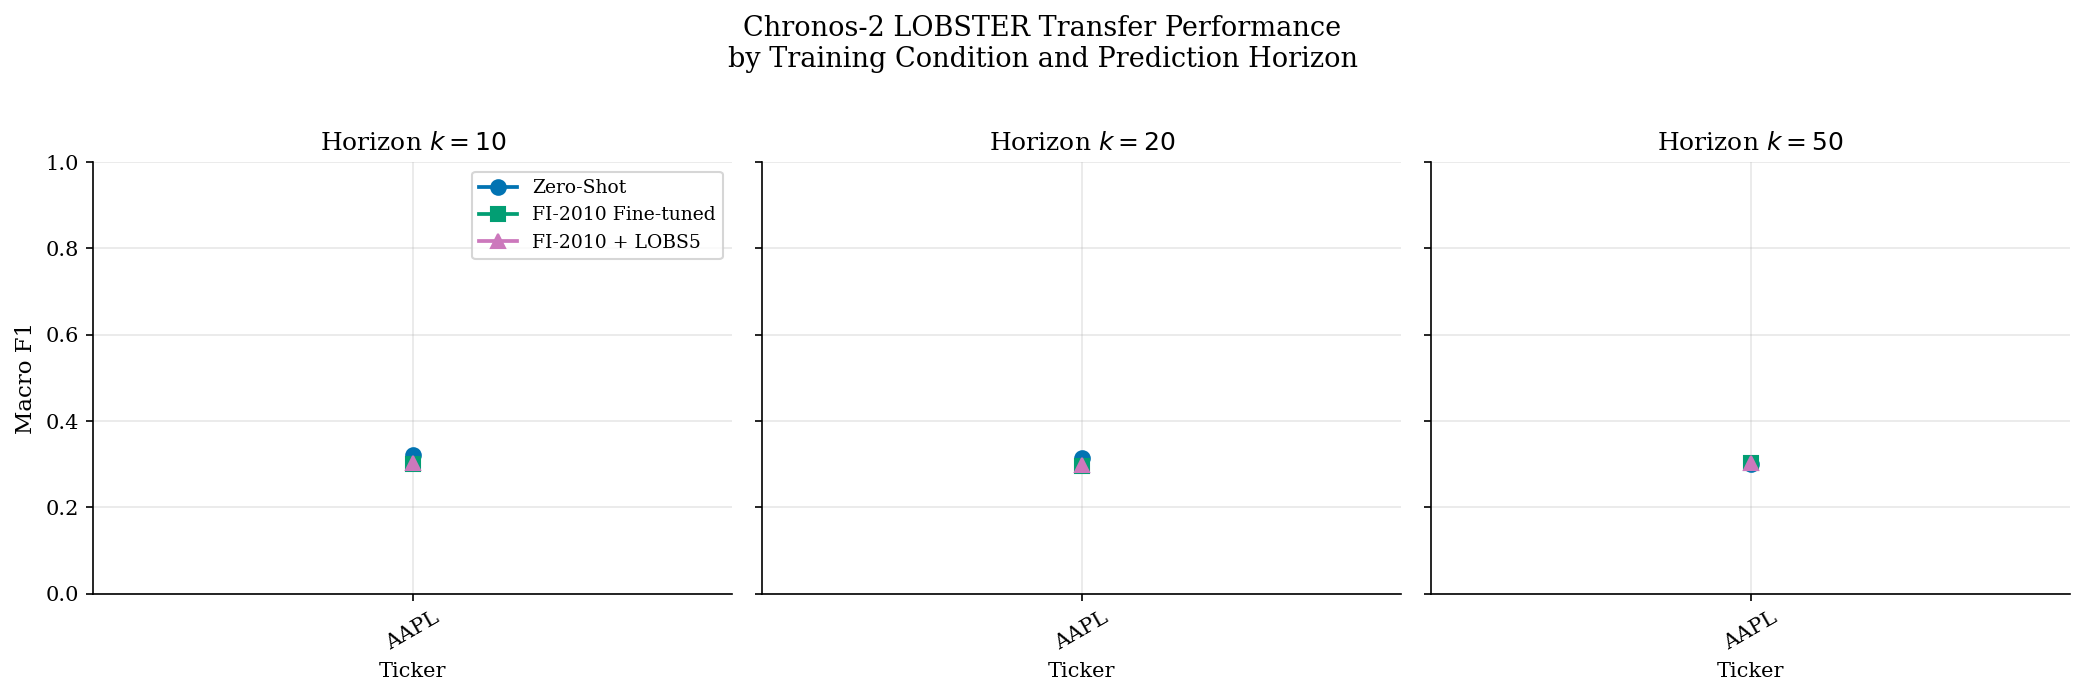

Saved: chronos2_f1_by_horizon.png


In [ ]:
# ── Figure 1: F1-macro by horizon and condition ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

condition_colors = {
    "Zero-Shot"         : PALETTE[0],
    "FI-2010 Fine-tuned": PALETTE[2],
    "FI-2010 + LOBS5"   : PALETTE[4],
}
condition_markers = {
    "Zero-Shot"         : "o",
    "FI-2010 Fine-tuned": "s",
    "FI-2010 + LOBS5"   : "^",
}

for ax, k in zip(axes, HORIZONS):
    k_data = all_results_df[all_results_df["k"] == k]
    for cond in condition_order:
        cond_data = k_data[k_data["Condition"] == cond]
        if cond_data.empty:
            continue
        tickers_sorted = sorted(cond_data["Ticker"].tolist())
        f1_vals = cond_data.set_index("Ticker").reindex(tickers_sorted)["F1 Macro"].values
        ax.plot(
            tickers_sorted, f1_vals,
            marker    = condition_markers[cond],
            color     = condition_colors[cond],
            linewidth = 1.8,
            markersize= 7,
            label     = cond,
        )
    ax.set_title(f"Horizon $k={k}$", fontsize=12)
    ax.set_xlabel("Ticker", fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Macro F1", fontsize=11)
axes[0].legend(fontsize=9, framealpha=0.8)

fig.suptitle(
    "Chronos-2 LOBSTER Transfer Performance\nby Training Condition and Prediction Horizon",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("chronos2_f1_by_horizon.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: chronos2_f1_by_horizon.png")

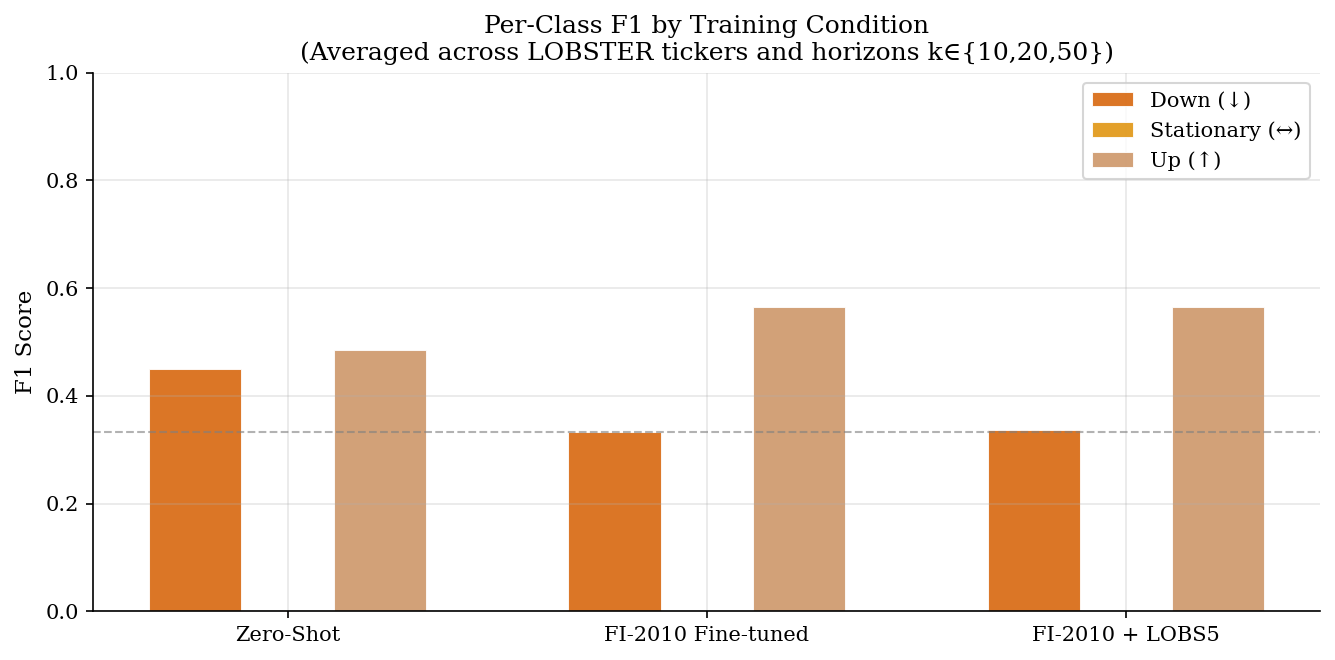

Saved: chronos2_per_class_f1.png


In [ ]:
# ── Figure 2: Per-class F1 breakdown ─────
mean_per_class = all_results_df.groupby("Condition")[["F1 Down", "F1 Stat", "F1 Up"]].mean()
mean_per_class = mean_per_class.reindex([c for c in condition_order if c in mean_per_class.index])
mean_per_class.columns = ["Down (↓)", "Stationary (↔)", "Up (↑)"]

fig, ax = plt.subplots(figsize=(9, 4.5))

x     = np.arange(len(mean_per_class.index))
width = 0.22
class_colors = [PALETTE[3], PALETTE[1], PALETTE[5]]

for j, (cls, color) in enumerate(zip(mean_per_class.columns, class_colors)):
    ax.bar(
        x + (j - 1) * width,
        mean_per_class[cls].values,
        width   = width,
        color   = color,
        alpha   = 0.85,
        label   = cls,
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(mean_per_class.index, fontsize=10)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_ylim(0, 1)
ax.set_title(
    "Per-Class F1 by Training Condition\n(Averaged across LOBSTER tickers and horizons k∈{10,20,50})",
    fontsize=12,
)
ax.legend(fontsize=10, framealpha=0.8)
ax.axhline(1/3, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Chance level")

plt.tight_layout()
plt.savefig("chronos2_per_class_f1.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: chronos2_per_class_f1.png")

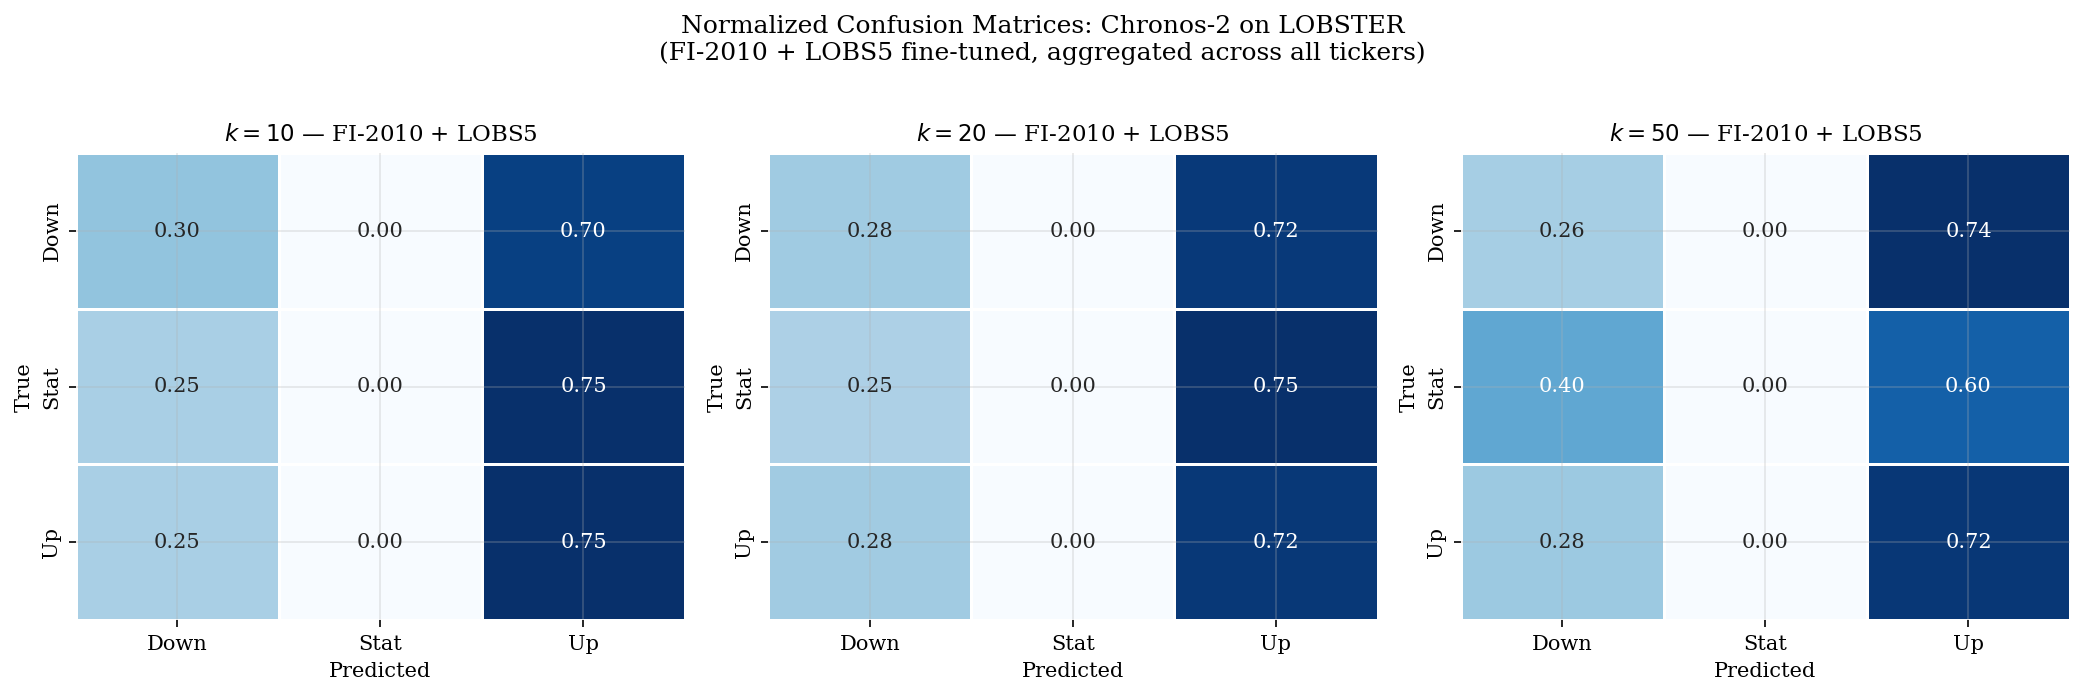

Saved: chronos2_confusion_matrices.png


In [ ]:
# ── Figure 3: Confusion matrices for best condition per horizon ────────────────
# Use FI-2010 + LOBS5 results; aggregate y_true / y_pred across tickers per horizon

def aggregate_predictions(results: List[Dict], horizon: int):
    y_trues, y_preds = [], []
    for r in results:
        if r.get("horizon") == horizon and "y_true" in r:
            y_trues.append(r["y_true"])
            y_preds.append(r["y_pred"])
    if not y_trues:
        return None, None
    return np.concatenate(y_trues), np.concatenate(y_preds)


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
class_labels = ["Down", "Stat", "Up"]

for ax, k in zip(axes, HORIZONS):
    y_true_all, y_pred_all = aggregate_predictions(combined_results, k)
    if y_true_all is None:
        ax.set_visible(False)
        continue
    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1, 2], normalize="true")
    sns.heatmap(
        cm,
        ax          = ax,
        annot       = True,
        fmt         = ".2f",
        cmap        = "Blues",
        xticklabels = class_labels,
        yticklabels = class_labels,
        cbar        = False,
        linewidths  = 0.5,
    )
    ax.set_title(f"$k={k}$ — FI-2010 + LOBS5", fontsize=11)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)

fig.suptitle(
    "Normalized Confusion Matrices: Chronos-2 on LOBSTER\n"
    "(FI-2010 + LOBS5 fine-tuned, aggregated across all tickers)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig("chronos2_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: chronos2_confusion_matrices.png")

In [ ]:
# ── Table 3: Full results table (publication-ready) ───────────────────────────
print("Table 3: Complete Chronos-2 Transfer Results")
print("(Macro-F1 | Accuracy | N samples per configuration)")
print("=" * 75)

full_table = all_results_df[
    ["Condition", "Ticker", "k", "F1 Macro", "F1 Down", "F1 Stat", "F1 Up", "Accuracy", "N Samples"]
].copy()
full_table["k"] = full_table["k"].map(lambda x: f"k={x}")

for col in ["F1 Macro", "F1 Down", "F1 Stat", "F1 Up", "Accuracy"]:
    full_table[col] = full_table[col].map("{:.4f}".format)

display(full_table.sort_values(["Condition", "Ticker", "k"]).reset_index(drop=True))

# Save to CSV for LaTeX integration
all_results_df.to_csv("chronos2_results.csv", index=False)
print("\nSaved: chronos2_results.csv")

Table 3: Complete Chronos-2 Transfer Results
(Macro-F1 | Accuracy | N samples per configuration)


,Condition,Ticker,k,F1 Macro,F1 Down,F1 Stat,F1 Up,Accuracy,N Samples
0,FI-2010 + LOBS5,AAPL,k=10,0.3019,0.3504,0.0000,0.5552,0.4365,2000
1,FI-2010 + LOBS5,AAPL,k=20,0.2984,0.3367,0.0000,0.5585,0.4480,2000
2,FI-2010 + LOBS5,AAPL,k=50,0.3023,0.3257,0.0000,0.5812,0.4745,2000
3,FI-2010 Fine-tuned,AAPL,k=10,0.2993,0.3438,0.0000,0.5542,0.4340,2000
4,FI-2010 Fine-tuned,AAPL,k=20,0.2961,0.3329,0.0000,0.5555,0.4450,2000
5,FI-2010 Fine-tuned,AAPL,k=50,0.3028,0.3238,0.0000,0.5845,0.4765,2000
6,Zero-Shot,AAPL,k=10,0.3221,0.4568,0.0000,0.5094,0.4395,2000
7,Zero-Shot,AAPL,k=20,0.3131,0.4467,0.0084,0.4843,0.4385,2000
8,Zero-Shot,AAPL,k=50,0.3011,0.4438,0.0000,0.4596,0.4425,2000



Saved: chronos2_results.csv


In [ ]:
# ── Transfer gain analysis: condition-over-condition deltas ───────────────────
print("Transfer Gain Analysis (ΔF1-macro relative to Zero-Shot)")
print("-" * 55)

mean_by_cond = all_results_df.groupby(["Condition", "k"])["F1 Macro"].mean().unstack(level=0)

if "Zero-Shot" in mean_by_cond.columns:
    for cond in ["FI-2010 Fine-tuned", "FI-2010 + LOBS5"]:
        if cond in mean_by_cond.columns:
            delta = mean_by_cond[cond] - mean_by_cond["Zero-Shot"]
            print(f"  {cond}:")
            for k in HORIZONS:
                if k in delta.index:
                    sign = "+" if delta[k] >= 0 else ""
                    print(f"    k={k:>2}: {sign}{delta[k]:.4f}")

    if all(c in mean_by_cond.columns for c in ["FI-2010 Fine-tuned", "FI-2010 + LOBS5"]):
        print()
        print("  LOBS5 synthetic augmentation gain over FI-2010 only:")
        lobs5_gain = mean_by_cond["FI-2010 + LOBS5"] - mean_by_cond["FI-2010 Fine-tuned"]
        for k in HORIZONS:
            if k in lobs5_gain.index:
                sign = "+" if lobs5_gain[k] >= 0 else ""
                print(f"    k={k:>2}: {sign}{lobs5_gain[k]:.4f}")

Transfer Gain Analysis (ΔF1-macro relative to Zero-Shot)
-------------------------------------------------------
  FI-2010 Fine-tuned:
    k=10: -0.0227
    k=20: -0.0170
    k=50: +0.0017
  FI-2010 + LOBS5:
    k=10: -0.0202
    k=20: -0.0147
    k=50: +0.0012

  LOBS5 synthetic augmentation gain over FI-2010 only:
    k=10: +0.0025
    k=20: +0.0023
    k=50: -0.0005
